In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# importing data and make a copy for safty
resturant_df = pd.read_excel(r"C:\Project_data\Restaurant_Dataset_1200_Rows.xlsx")
df = resturant_df.copy()

# Findings #

- ***PreProcessing_Phase***

    - Rows and Columns

        - This Dataset has 1211 rows with 20 columns
        - after duplicate check in order id 1178 rows 
        
    - Duplicate
        - only 10 duplicates before analysis
        - and 33 duplicate in primary_key (Order_ID) 

    - Wrong DataType
        - Order_Date stored as string  
        - Rating unnesessary stored as float 
        - age stored as string 
        - (Tip,Discount,Delivery_Fee,Delivery_Time) without floating values but stored as float 

    - Missing values
        - Age column has 18.90% null values and total null 229
        - Discount column has 17.42% null values and total null 211
        - Delivery_Fee column has 24.69% null values and total null 299
        - Tip column has 20.64% null values and total null 250

- ***EDA***
    
    *Total Amount*
    - no missing value
    - 468 orders with total amount 0 or less 39.73%
    - right skwed most people pay under 1000
    - less than 0 is 29% 
    - i check df.iloc[25] here i found which is a valid trnsaction but i notice one thing customer_name is priya which looks like a female but gender column  has a value male 
    *Rating*
    - total 136 null values 11.54%
    - 153 negative rating how if rating between(1-5 or 1-6)
    - rating is slightly higher  
    - and aasuming people who are disapointed they rated 1 or -1 which can be a data entry error 

    *Age*
    - Total 228 values with age of 0 or less than 0 which is imposiable 
    - Total 249 values with age of 80 or greater than 80 which is almost impractical
    - Total 477 (40.49%)invalid age + 223 null makes it unpredictable for future use

    *Gender*
    - In Gender column total 365 Unnown Values which is 30.98% 
    - but no missing values 
    - if replace unknown with mode this become useless because all 3 divided almost equally just leaving it a better option i feel
    - females spend more in pizza(601 avg 82 order) and males spend more in noodles (541 avg 88 order)
    - females 

    *City*
    - hyderabad dominate with 460 orders while others are around 150 
    - and mumbai is the lowest with 134 orders

    *Resturant*
    - all resturants perform well but food palace leads other with 251 orders in all citys
    - and pizza point is the lowest with 219 orders in citys

    *Cuisine*
    - highest order cuisine is north indian with 569 orders in all citys and resturant 
    - and the lowest is south indian 186 orders only 

    *Item*
    - highest order tem is pizza with 217 orders in all citys and resturant 
    - and the lowest is paneer with 174 orders 
    - all orders with unique item

    *Quantity*
    - 203 orders with 0 quantity 
        - Pending      78
        - Delivered    64
        - Cancelled    61
    - 60 orders out of 64 delivered orders is paid greter than 0 
    - it is maybe a error by our side 

    - hyderabad with 87 orders with quantity 0 highest
    - puri with 18 orders with quantity 0 lowest 
    - error recodered in hydrabad city 26 highest and cuttack city 6 lowest status delivered quantity 0 
    - error recodered in noodles item 13 highest and paneer with 8 lowest status delivered quantity 0 
    - error recodered in spice hub returant 18 highest and tandoor town 8 lowest 

    **Bi or multi model check**

    - hydrabad customrs mostly orde either 4-5 quantity or 1-2 quantity 
    - 

    *low seller*

    - Biryani house in Bhubaneswar and Tandoor Town in puri with lowest order 20 
    - people of puri are not showing interest in south indian cuisine
    - Biryani house's south indian disees and chinese from pizza point are showing low interest by our customers 
    - puri customers dont like paneer and mumbai customers dont like biryani 
    - pizza points burger low selling


    **Drop data and reason**

        - assuming a valid of 10-70(can eat and pay the bill) and total 240 record found almost 20.37% that means almost 80% data is invalid or missing so cant get the best result of the age column analysis because i cant predict (filling data) with 20% valid data so no analysis made in age column i am going to drop it (fiiling with median and use age in further analysis can give wrong answers)
        
        - drop gender 


**Data Pre Precossesing**

In [3]:
print(f"Shape : {df.shape}")

Shape : (1211, 20)


In [4]:
(df.duplicated().sum()/df.shape[0])*100

np.float64(0.8257638315441783)

In [5]:
df.duplicated().sum()

np.int64(10)

In [6]:
df.drop_duplicates(subset=["Order_ID"],inplace=True)

In [7]:
df.shape

(1178, 20)

In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 1178 entries, 0 to 1200
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1178 non-null   str    
 1   Order_Date        1178 non-null   str    
 2   Customer_Name     1150 non-null   str    
 3   Age               955 non-null    object 
 4   Gender            1178 non-null   str    
 5   City              1178 non-null   str    
 6   Restaurant_Name   1178 non-null   str    
 7   Cuisine           1178 non-null   str    
 8   Item              1178 non-null   str    
 9   Quantity          1178 non-null   int64  
 10  Price             1178 non-null   float64
 11  Discount          973 non-null    float64
 12  Delivery_Fee      884 non-null    float64
 13  Payment_Method    1178 non-null   str    
 14  Rating            1042 non-null   float64
 15  Delivery_Time     1010 non-null   float64
 16  Order_Status      1178 non-null   str    
 17  Tip        

In [9]:
df.head()

,Order_ID,Order_Date,Customer_Name,Age,Gender,City,Restaurant_Name,Cuisine,Item,Quantity,Price,Discount,Delivery_Fee,Payment_Method,Rating,Delivery_Time,Order_Status,Tip,Total_Amount,Delivery_Partner
0,ORD1000,2025-05-28,Amit,150,Unknown,Mumbai,Food Palace,Chinese,Dosa,4,-50.00,5.0,20.0,Cash,6.0,20.0,Cancelled,20.0,-150.00,Dunzo
1,ORD1001,2025-08-28,Rohit,NaN,Male,hyderabad,Spice Hub,North indian,Biryani,2,105.02,NaN,20.0,UPI,2.0,30.0,Delivered,0.0,230.04,Zomato
2,ORD1002,2026-01-13,Anita,NaN,Male,Hyderabad,Spice Hub,North indian,Paneer,0,723.06,20.0,20.0,Cash,6.0,20.0,Cancelled,NaN,20.00,Swiggy
3,ORD1003,2025-05-01,Pooja,-5,Female,Hyderabad,Tandoor Town,South Indian,Paneer,0,667.56,10.0,30.0,Card,5.0,45.0,Pending,50.0,80.00,Dunzo
4,ORD1004,2025-09-23,Riya,Unknown,Female,Hyderabad,Pizza Point,South Indian,Pizza,1,-50.00,15.0,20.0,Wallet,NaN,NaN,Cancelled,50.0,27.50,Dunzo


In [10]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [11]:
df["City"].unique()

<StringArray>
[     'Mumbai',   'hyderabad',  'Hyderabad ',     'Cuttack',   'HYDERABAD',
       'Delhi', 'Bhubaneswar',        'Puri']
Length: 8, dtype: str

In [12]:
df["City"] = df["City"].str.strip().str.lower()

In [13]:
df["Cuisine"].unique()

<StringArray>
[     'Chinese', 'North indian', 'South Indian', 'north indian',
      'Italian', 'North Indian']
Length: 6, dtype: str

In [14]:
df["Cuisine"] = df["Cuisine"].str.strip().str.lower()

In [15]:
df["Item"].unique()

<StringArray>
['Dosa', 'Biryani', 'Paneer', 'Pizza', 'Noodles', 'Burger']
Length: 6, dtype: str

In [16]:
df["Restaurant_Name"].unique()

<StringArray>
['Food Palace', 'Spice Hub', 'Tandoor Town', 'Pizza Point', 'Biryani House']
Length: 5, dtype: str

In [17]:
df["Order_Status"]  = df["Order_Status"].str.strip().str.lower()

In [18]:
df.sample(10)

,Order_ID,Order_Date,Customer_Name,Age,Gender,City,Restaurant_Name,Cuisine,Item,Quantity,Price,Discount,Delivery_Fee,Payment_Method,Rating,Delivery_Time,Order_Status,Tip,Total_Amount,Delivery_Partner
132,ORD1132,2025-02-19,Anita,63,Female,hyderabad,Spice Hub,italian,Noodles,5,735.37,5.0,20.0,UPI,6.0,45.0,delivered,50.0,3563.01,Swiggy
551,ORD1551,2025-02-07,Riya,150,Male,delhi,Biryani House,chinese,Pizza,0,-50.00,15.0,30.0,Wallet,5.0,60.0,pending,50.0,80.00,Zomato
1046,ORD2046,2025-04-18,Amit,Unknown,Female,puri,Pizza Point,chinese,Burger,0,-50.00,5.0,30.0,UPI,5.0,45.0,pending,20.0,50.00,Swiggy
484,ORD1484,2026-03-03,Pooja,150,Female,mumbai,Pizza Point,chinese,Pizza,0,-50.00,5.0,30.0,Card,5.0,60.0,delivered,NaN,30.00,Dunzo
374,ORD1374,2026-03-04,Amit,39,Unknown,hyderabad,Pizza Point,north indian,Pizza,3,-50.00,15.0,20.0,Cash,3.0,45.0,cancelled,NaN,-107.50,Swiggy
792,ORD1792,2025-11-24,Priya,NaN,Male,hyderabad,Spice Hub,south indian,Pizza,5,524.10,10.0,40.0,Card,6.0,NaN,pending,0.0,2398.45,Zomato
569,ORD1569,2025-08-25,Pooja,21,Unknown,mumbai,Tandoor Town,italian,Biryani,0,-50.00,15.0,NaN,Card,3.0,60.0,pending,NaN,0.00,Zomato
450,ORD1450,2025-03-26,Anita,Unknown,Female,bhubaneswar,Tandoor Town,north indian,Biryani,5,672.07,0.0,40.0,Wallet,6.0,20.0,cancelled,0.0,3400.35,Zomato
1198,ORD2198,2026-02-09,Karan,Unknown,Unknown,hyderabad,Tandoor Town,chinese,Paneer,0,-50.00,NaN,20.0,UPI,5.0,20.0,cancelled,0.0,20.00,Zomato
1036,ORD2036,2025-12-13,Priya,45,Male,cuttack,Food Palace,south indian,Dosa,0,787.98,NaN,40.0,Wallet,2.0,45.0,delivered,30.0,70.00,Swiggy


In [19]:
print(f"\nis null percentage :\n{(df.isna().sum()/df.shape[0])*100}")


is null percentage :
Order_ID             0.000000
Order_Date           0.000000
Customer_Name        2.376910
Age                 18.930390
Gender               0.000000
City                 0.000000
Restaurant_Name      0.000000
Cuisine              0.000000
Item                 0.000000
Quantity             0.000000
Price                0.000000
Discount            17.402377
Delivery_Fee        24.957555
Payment_Method       0.000000
Rating              11.544992
Delivery_Time       14.261460
Order_Status         0.000000
Tip                 20.288625
Total_Amount         0.000000
Delivery_Partner     0.000000
dtype: float64


In [20]:
print(f"\nis null value :\n{df.isna().sum()}")


is null value :
Order_ID              0
Order_Date            0
Customer_Name        28
Age                 223
Gender                0
City                  0
Restaurant_Name       0
Cuisine               0
Item                  0
Quantity              0
Price                 0
Discount            205
Delivery_Fee        294
Payment_Method        0
Rating              136
Delivery_Time       168
Order_Status          0
Tip                 239
Total_Amount          0
Delivery_Partner      0
dtype: int64


In [21]:
df.skew(numeric_only=True)

Quantity         0.016776
Price            0.714070
Discount        -0.028351
Delivery_Fee     0.042131
Rating          -0.322045
Delivery_Time    0.568620
Tip             -0.007282
Total_Amount     1.745038
dtype: float64

In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 1178 entries, 0 to 1200
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          1178 non-null   str           
 1   Order_Date        1178 non-null   datetime64[us]
 2   Customer_Name     1150 non-null   str           
 3   Age               955 non-null    object        
 4   Gender            1178 non-null   str           
 5   City              1178 non-null   str           
 6   Restaurant_Name   1178 non-null   str           
 7   Cuisine           1178 non-null   str           
 8   Item              1178 non-null   str           
 9   Quantity          1178 non-null   int64         
 10  Price             1178 non-null   float64       
 11  Discount          973 non-null    float64       
 12  Delivery_Fee      884 non-null    float64       
 13  Payment_Method    1178 non-null   str           
 14  Rating            1042 non-null   float6

# Data_Cleaning #


**Total Amount**

In [23]:
df["Total_Amount"].isna().sum()

np.int64(0)

In [24]:
df["Total_Amount"].skew()

np.float64(1.745038378722527)

<Axes: xlabel='Total_Amount', ylabel='Count'>

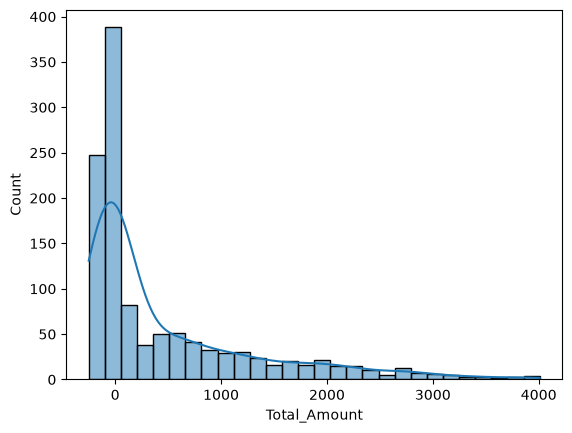

In [25]:
sns.histplot(df["Total_Amount"],kde=True)

In [26]:
round(((df["Total_Amount"] <= 0).sum() / df.shape[0]) * 100,2)

np.float64(39.73)

In [27]:
Q1 = np.percentile(df["Total_Amount"],25)
Q2 = np.percentile(df["Total_Amount"],50)
Q3 = np.percentile(df["Total_Amount"],75)
Max = np.percentile(df["Total_Amount"],100)
Min = np.percentile(df["Total_Amount"],0)
IQR = Q3 - Q1
print(f"Minimum value : {Min}")
print(f"Maximum value : {Max}")
print(f"25 per. value : {Q1}")
print(f"50 per. value : {Q2}")
print(f"75 per. value : {Q3}")

Minimum value : -250.0
Maximum value : 4008.6
25 per. value : -75.0
50 per. value : 40.0
75 per. value : 736.805


In [28]:
# x = 0
# z = round((x - np.mean(df["Total_Amount"])/np.std(df["Total_Amount"])),2)
# z
# p_value = round(stats.norm.cdf(z) * 100) 
# print(f"Z-table value (area to the left) of {x} : {p_value} %") 
# the z score performed is giving wrong ans because it is a skewded data

In [29]:
round(((df[df["Total_Amount"] < 0]["Total_Amount"].count())/df.shape[0])*100,2)

np.float64(37.61)

In [30]:
round(((df[df["Total_Amount"] == 0]["Total_Amount"].count())/df.shape[0])*100,2)


np.float64(2.12)

In [31]:
large_totalamount = df.nlargest(10, "Total_Amount")
large_totalamount

,Order_ID,Order_Date,Customer_Name,Age,Gender,City,Restaurant_Name,Cuisine,Item,Quantity,Price,Discount,Delivery_Fee,Payment_Method,Rating,Delivery_Time,Order_Status,Tip,Total_Amount,Delivery_Partner
25,ORD1025,2025-01-20,Priya,150,Male,delhi,Food Palace,north indian,Paneer,5,783.72,NaN,40.0,UPI,5.0,90.0,delivered,50.0,4008.60,Swiggy
135,ORD1135,2026-05-21,Rahul,-5,Female,hyderabad,Food Palace,italian,Pizza,5,794.08,NaN,30.0,UPI,-1.0,30.0,cancelled,NaN,4000.40,Dunzo
838,ORD1838,2025-10-03,Rahul,-5,Male,hyderabad,Food Palace,chinese,Pizza,5,790.84,NaN,NaN,Wallet,6.0,60.0,pending,NaN,3954.20,Dunzo
636,ORD1636,2026-02-09,Rahul,NaN,Female,hyderabad,Spice Hub,north indian,Pizza,5,783.43,0.0,NaN,Cash,5.0,30.0,cancelled,NaN,3917.15,Swiggy
1190,ORD2190,2025-06-01,Anita,Unknown,Female,bhubaneswar,Biryani House,chinese,Paneer,5,752.46,NaN,20.0,UPI,6.0,90.0,pending,30.0,3812.30,Swiggy
599,ORD1599,2025-03-15,Riya,18,Female,mumbai,Spice Hub,north indian,Noodles,5,797.65,5.0,20.0,Wallet,2.0,60.0,delivered,0.0,3808.84,Dunzo
587,ORD1587,2026-01-03,Sneha,NaN,Unknown,hyderabad,Spice Hub,chinese,Biryani,5,743.83,NaN,NaN,Card,5.0,30.0,pending,50.0,3769.15,Swiggy
261,ORD1261,2025-10-20,Amit,150,Male,delhi,Spice Hub,north indian,Paneer,5,787.49,10.0,40.0,Card,1.0,90.0,pending,0.0,3583.70,Dunzo
132,ORD1132,2025-02-19,Anita,63,Female,hyderabad,Spice Hub,italian,Noodles,5,735.37,5.0,20.0,UPI,6.0,45.0,delivered,50.0,3563.01,Swiggy
617,ORD1617,2025-01-13,Karan,-5,Male,delhi,Pizza Point,italian,Dosa,5,696.26,NaN,NaN,Card,NaN,45.0,delivered,0.0,3481.30,Dunzo


In [32]:
df.iloc[135]

Order_ID                        ORD1137
Order_Date          2026-01-26 00:00:00
Customer_Name                     Karan
Age                                 NaN
Gender                          Unknown
City                          hyderabad
Restaurant_Name            Tandoor Town
Cuisine                    north indian
Item                             Burger
Quantity                              3
Price                            303.24
Discount                           20.0
Delivery_Fee                       40.0
Payment_Method                   Wallet
Rating                             -1.0
Delivery_Time                      45.0
Order_Status                    pending
Tip                                 NaN
Total_Amount                     767.78
Delivery_Partner                 Swiggy
Name: 137, dtype: object

In [33]:
for index, row in large_totalamount.iterrows():
    # 1. Safely extract values and fill missing/NaN values with 0
    price = 0 if pd.isna(row['Price']) else row['Price']
    quantity = 0 if pd.isna(row['Quantity']) else row['Quantity']
    discount = 0 if pd.isna(row['Discount']) else row['Discount']
    delivery_fee = 0 if pd.isna(row['Delivery_Fee']) else row['Delivery_Fee']
    tip = 0 if pd.isna(row['Tip']) else row['Tip']
    
    # 2. Perform the step-by-step math
    subtotal = price * quantity
    discount_factor = 1 - (discount / 100)
    calculated_total = round((subtotal * discount_factor) + delivery_fee + tip, 2)
    
    # 3. Print out the clean comparison
    print(f"Row {index} | Order ID: {row['Order_ID']}")
    print(f" -> Calculated: {calculated_total} | Original in DF: {row['Total_Amount']}")
    print("-" * 40)



Row 25 | Order ID: ORD1025
 -> Calculated: 4008.6 | Original in DF: 4008.6
----------------------------------------
Row 135 | Order ID: ORD1135
 -> Calculated: 4000.4 | Original in DF: 4000.4
----------------------------------------
Row 838 | Order ID: ORD1838
 -> Calculated: 3954.2 | Original in DF: 3954.2
----------------------------------------
Row 636 | Order ID: ORD1636
 -> Calculated: 3917.15 | Original in DF: 3917.15
----------------------------------------
Row 1190 | Order ID: ORD2190
 -> Calculated: 3812.3 | Original in DF: 3812.3
----------------------------------------
Row 599 | Order ID: ORD1599
 -> Calculated: 3808.84 | Original in DF: 3808.84
----------------------------------------
Row 587 | Order ID: ORD1587
 -> Calculated: 3769.15 | Original in DF: 3769.15
----------------------------------------
Row 261 | Order ID: ORD1261
 -> Calculated: 3583.7 | Original in DF: 3583.7
----------------------------------------
Row 132 | Order ID: ORD1132
 -> Calculated: 3563.01 | Orig

**Delivery Fee**

**Delivery Time**

**Rating Column**

In [34]:
# (df["Rating"].isna().sum()/df.shape[0])*100
df["Rating"].isna().sum()

np.int64(136)

In [35]:
df["Rating"].unique()

array([ 6.,  2.,  5., nan,  4., -1.,  1.,  3.])

In [36]:
(df["Rating"] == -1).sum()

np.int64(153)

<Axes: xlabel='Rating', ylabel='Count'>

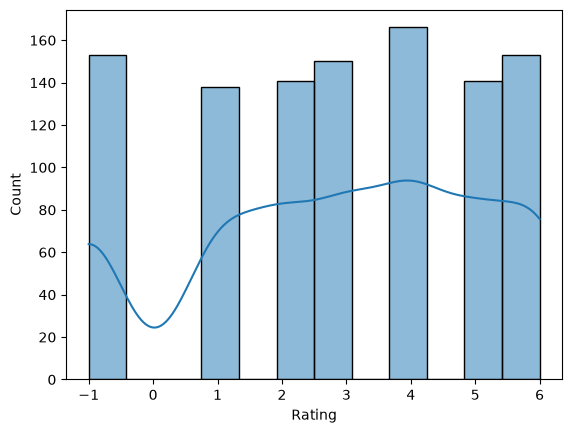

In [37]:
sns.histplot(df["Rating"],kde=True)

<Axes: ylabel='Rating'>

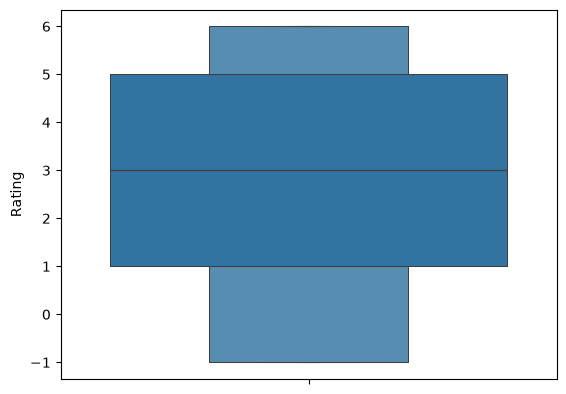

In [38]:
sns.boxenplot(df["Rating"])

In [39]:
Rating_Median = df["Rating"].median()
Rating_Median

np.float64(3.0)

In [40]:
df["Rating"] = df["Rating"].fillna(Rating_Median)

In [41]:
df["Rating"].isna().sum()

np.int64(0)

In [42]:
df["Rating"] = df["Rating"].astype(int)

**Age Column**

In [43]:
df["Age"].isna().sum()

np.int64(223)

In [44]:
df["Age"].unique()

array([150, nan, -5, 'Unknown', 21, 47, 38, 52, 46, 64, 33, 41, 40, 51,
       56, 37, 65, 32, 25, 18, 34, 20, 60, 54, 63, 30, 35, 58, 39, 49, 26,
       59, 50, 45, 28, 19, 55, 22, 27, 57, 42, 43, 23, 24, 53, 48, 44, 36,
       29, 62, 31, 61], dtype=object)

In [45]:
df["Age"] = df["Age"].replace("Unknown", np.nan)

In [46]:
df["Age"].skew()

np.float64(0.3597630262655176)

<Axes: xlabel='Age', ylabel='Count'>

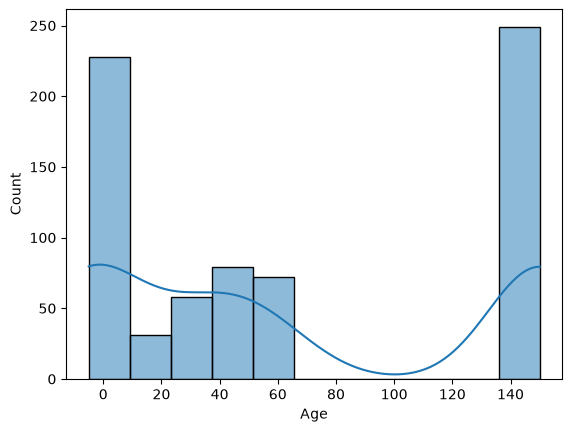

In [47]:
sns.histplot(df["Age"],kde=True)

<Axes: ylabel='Age'>

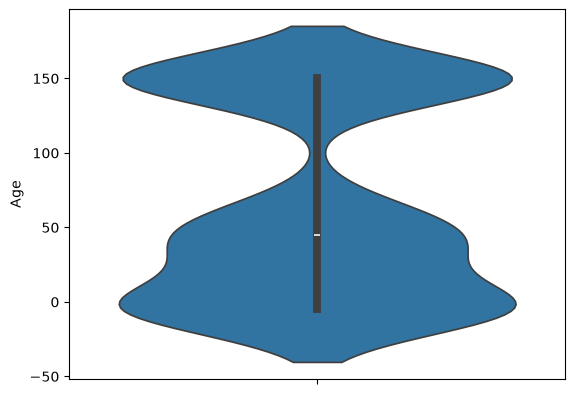

In [48]:
sns.violinplot(df["Age"])

In [49]:
df[df["Age"] <= 0]

,Order_ID,Order_Date,Customer_Name,Age,Gender,City,Restaurant_Name,Cuisine,Item,Quantity,Price,Discount,Delivery_Fee,Payment_Method,Rating,Delivery_Time,Order_Status,Tip,Total_Amount,Delivery_Partner
3,ORD1003,2025-05-01,Pooja,-5,Female,hyderabad,Tandoor Town,south indian,Paneer,0,667.56,10.0,30.0,Card,5,45.0,pending,50.0,80.00,Dunzo
7,ORD1007,2025-04-18,Priya,-5,Unknown,delhi,Biryani House,north indian,Pizza,4,-50.00,20.0,40.0,Wallet,4,60.0,pending,20.0,-100.00,Zomato
19,ORD1019,2025-09-18,Pooja,-5,Male,hyderabad,Tandoor Town,north indian,Dosa,5,411.53,15.0,40.0,Card,4,45.0,delivered,20.0,1809.00,Swiggy
21,ORD1021,2025-05-26,Rahul,-5,Unknown,delhi,Biryani House,chinese,Pizza,2,-50.00,15.0,30.0,UPI,-1,60.0,pending,50.0,-5.00,Zomato
27,ORD1027,2025-01-04,Pooja,-5,Unknown,bhubaneswar,Biryani House,north indian,Burger,4,-50.00,15.0,30.0,UPI,2,30.0,cancelled,30.0,-110.00,Swiggy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1186,ORD2186,2026-03-13,NaN,-5,Female,hyderabad,Pizza Point,chinese,Pizza,2,-50.00,10.0,NaN,Wallet,2,45.0,pending,30.0,-60.00,Dunzo
1188,ORD2188,2025-05-23,Karan,-5,Female,hyderabad,Food Palace,north indian,Burger,3,563.01,5.0,30.0,Cash,2,60.0,cancelled,50.0,1684.58,Dunzo
1196,ORD2196,2026-05-16,Somanath,-5,Unknown,hyderabad,Spice Hub,north indian,Dosa,1,-50.00,5.0,NaN,Card,6,NaN,delivered,20.0,-27.50,Zomato
1199,ORD2199,2025-07-21,Rahul,-5,Male,hyderabad,Pizza Point,north indian,Paneer,2,-50.00,10.0,40.0,Cash,3,20.0,cancelled,50.0,0.00,Zomato


In [50]:
df[df["Age"] >= 80]

,Order_ID,Order_Date,Customer_Name,Age,Gender,City,Restaurant_Name,Cuisine,Item,Quantity,Price,Discount,Delivery_Fee,Payment_Method,Rating,Delivery_Time,Order_Status,Tip,Total_Amount,Delivery_Partner
0,ORD1000,2025-05-28,Amit,150,Unknown,mumbai,Food Palace,chinese,Dosa,4,-50.00,5.0,20.0,Cash,6,20.0,cancelled,20.0,-150.00,Dunzo
5,ORD1005,2025-10-01,Priya,150,Unknown,cuttack,Pizza Point,north indian,Noodles,3,552.42,0.0,40.0,Wallet,4,20.0,delivered,NaN,1697.26,Swiggy
14,ORD1014,2025-08-15,Pooja,150,Unknown,puri,Food Palace,north indian,Biryani,1,720.23,NaN,40.0,UPI,1,30.0,pending,50.0,810.23,Dunzo
18,ORD1018,2025-07-22,Rahul,150,Unknown,delhi,Pizza Point,italian,Pizza,1,-50.00,5.0,20.0,Card,1,90.0,pending,NaN,-27.50,Swiggy
20,ORD1020,2025-06-03,NaN,150,Unknown,delhi,Tandoor Town,italian,Pizza,0,-50.00,5.0,NaN,Card,3,20.0,cancelled,20.0,20.00,Swiggy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1173,ORD2173,2025-02-28,Somanath,150,Male,hyderabad,Food Palace,north indian,Biryani,4,-50.00,0.0,NaN,Cash,3,NaN,pending,30.0,-170.00,Swiggy
1182,ORD2182,2025-06-14,Karan,150,Unknown,mumbai,Tandoor Town,south indian,Pizza,5,131.29,0.0,40.0,Wallet,1,NaN,cancelled,NaN,696.45,Zomato
1189,ORD2189,2025-01-14,Amit,150,Male,mumbai,Biryani House,north indian,Paneer,4,-50.00,NaN,20.0,UPI,4,90.0,delivered,NaN,-180.00,Swiggy
1191,ORD2191,2025-02-07,Sneha,150,Male,puri,Food Palace,north indian,Noodles,5,693.24,20.0,40.0,Wallet,1,20.0,cancelled,20.0,2832.96,Zomato


In [51]:
invalid_age_count = (((df["Age"] >= 80) | (df["Age"] <= 0)).sum() / df.shape[0])*100
round(invalid_age_count,2)

np.float64(40.49)

In [52]:
valid_age = ((df["Age"] >= 10) & (df["Age"] <= 70)).sum()
valid_age/df.shape[0]*100

np.float64(20.37351443123939)

In [53]:
df.drop(columns=["Age"],inplace=True)

**Gender Column**


In [54]:
df["Gender"].isna().sum()

np.int64(0)

In [55]:
df["Gender"].value_counts()/df.shape[0]*100

Gender
Male       36.502547
Female     32.512733
Unknown    30.984720
Name: count, dtype: float64

<Axes: xlabel='count', ylabel='Gender'>

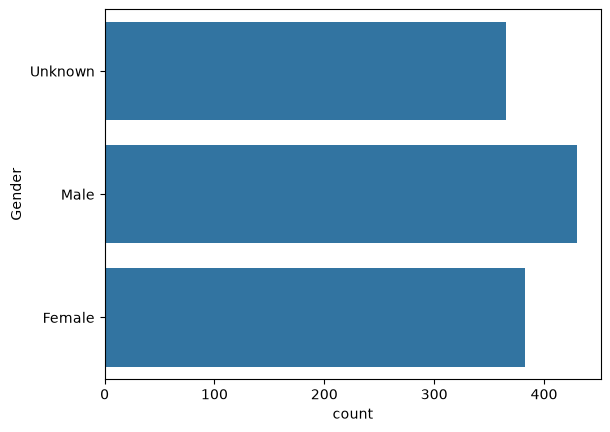

In [56]:
sns.countplot(df["Gender"])

**City Column**

<Axes: xlabel='City', ylabel='count'>

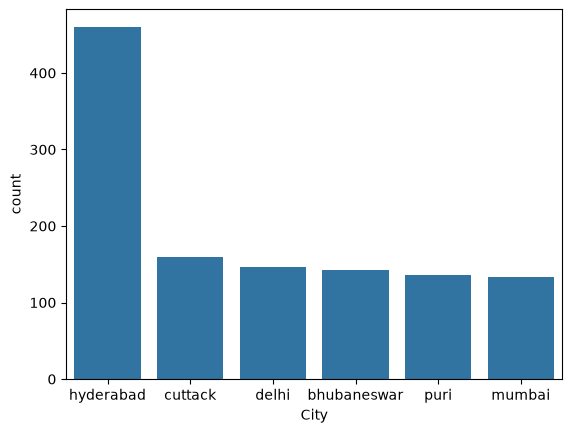

In [57]:
sns.barplot(df["City"].value_counts())

In [58]:
df["City"].value_counts()

City
hyderabad      460
cuttack        159
delhi          146
bhubaneswar    143
puri           136
mumbai         134
Name: count, dtype: int64

**Resturant Column**

In [59]:
df["Restaurant_Name"].value_counts()

Restaurant_Name
Food Palace      251
Spice Hub        243
Biryani House    240
Tandoor Town     225
Pizza Point      219
Name: count, dtype: int64

**Cuisine Column**

In [60]:
df["Cuisine"].value_counts()

Cuisine
north indian    569
chinese         216
italian         207
south indian    186
Name: count, dtype: int64

<Axes: ylabel='Cuisine'>

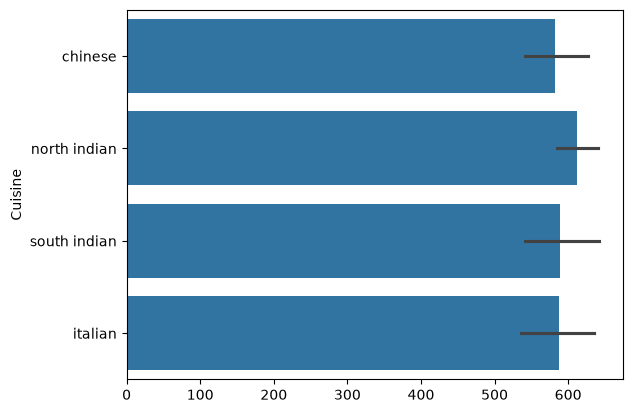

In [61]:
sns.barplot(df["Cuisine"])

<Axes: xlabel='Cuisine', ylabel='Rating'>

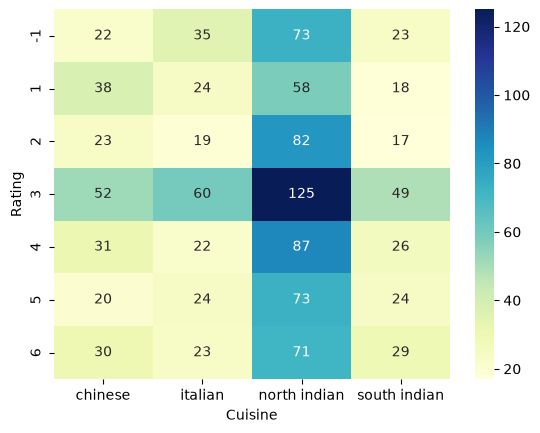

In [62]:
pivot_data = df.groupby(['Rating', 'Cuisine']).size().unstack(fill_value=0)
sns.heatmap(pivot_data, annot=True, fmt='d',cmap='YlGnBu')

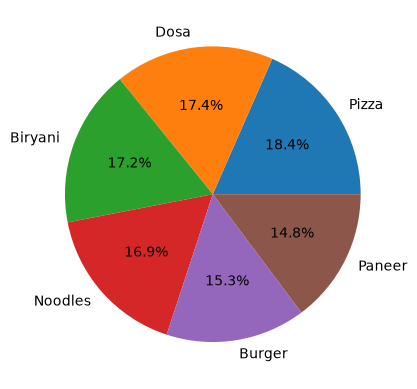

In [63]:
plt.pie(df["Item"].value_counts(), labels=df["Item"].value_counts().index, autopct='%1.1f%%')
plt.show()

**Item Column**

In [64]:
df["Item"].value_counts()

Item
Pizza      217
Dosa       205
Biryani    203
Noodles    199
Burger     180
Paneer     174
Name: count, dtype: int64

<Axes: ylabel='Item'>

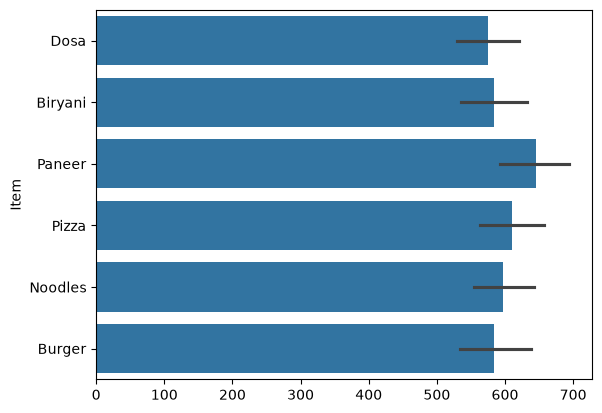

In [65]:
sns.barplot(df["Item"])

**Quantity Column**

In [66]:
df["Quantity"].value_counts()

Quantity
5    221
0    203
1    203
2    186
3    184
4    181
Name: count, dtype: int64

In [67]:
df.head()

,Order_ID,Order_Date,Customer_Name,Gender,City,Restaurant_Name,Cuisine,Item,Quantity,Price,Discount,Delivery_Fee,Payment_Method,Rating,Delivery_Time,Order_Status,Tip,Total_Amount,Delivery_Partner
0,ORD1000,2025-05-28,Amit,Unknown,mumbai,Food Palace,chinese,Dosa,4,-50.00,5.0,20.0,Cash,6,20.0,cancelled,20.0,-150.00,Dunzo
1,ORD1001,2025-08-28,Rohit,Male,hyderabad,Spice Hub,north indian,Biryani,2,105.02,NaN,20.0,UPI,2,30.0,delivered,0.0,230.04,Zomato
2,ORD1002,2026-01-13,Anita,Male,hyderabad,Spice Hub,north indian,Paneer,0,723.06,20.0,20.0,Cash,6,20.0,cancelled,NaN,20.00,Swiggy
3,ORD1003,2025-05-01,Pooja,Female,hyderabad,Tandoor Town,south indian,Paneer,0,667.56,10.0,30.0,Card,5,45.0,pending,50.0,80.00,Dunzo
4,ORD1004,2025-09-23,Riya,Female,hyderabad,Pizza Point,south indian,Pizza,1,-50.00,15.0,20.0,Wallet,3,NaN,cancelled,50.0,27.50,Dunzo


In [68]:
# 1. Skip pd.cut and use individual quantities directly
# (This creates a column for every unique number like 0, 1, 2, 3, 4, 5)
qty_matrix = pd.col_order = sorted(df["Quantity"].unique()) # Get sorted list of numbers

# 2. Create the crosstab matrix using raw numbers
qty_matrix = pd.crosstab(
    df["City"], 
    df["Quantity"], 
    margins=True, 
    margins_name="Total Order Quantity"
)

# 3. Separate the total row from the city data
total_row = qty_matrix.loc[["Total Order Quantity"]]
cities_only = qty_matrix.drop("Total Order Quantity")

# 4. Sort the cities by column 1 (or change to whichever number you want to rank by)
# Then append the total row back to the bottom
cities_sorted = cities_only.sort_values(by=1, ascending=False)
qty_matrix = pd.concat([cities_sorted, total_row])

# 5. Apply visual styling with black text and light background
def highlight_totals(x):
    style_df = pd.DataFrame('', index=x.index, columns=x.columns)
    
    row_style = 'background-color: #E6F2FF; color: black; font-weight: bold; border-top: 2px solid #A0A0A0;'
    col_style = 'background-color: #E6F2FF; color: black; font-weight: bold; border-left: 2px solid #A0A0A0;'
    intersect_style = 'background-color: #CCE5FF; color: black; font-weight: bold; border-top: 2px solid #A0A0A0; border-left: 2px solid #A0A0A0;'
    
    style_df.iloc[-1, :] = row_style
    style_df.iloc[:, -1] = col_style
    style_df.iloc[-1, -1] = intersect_style
    
    return style_df

# Display the styled matrix
styled_matrix = qty_matrix.style.apply(highlight_totals, axis=None)
display(styled_matrix)


Quantity,0,1,2,3,4,5,Total Order Quantity
City,,,,,,,
hyderabad,87,77,70,74,66,86,460
delhi,24,29,24,19,24,26,146
puri,18,28,27,16,15,32,136
cuttack,23,27,29,26,28,26,159
bhubaneswar,27,23,18,28,21,26,143
mumbai,24,19,18,21,27,25,134
Total Order Quantity,203,203,186,184,181,221,1178


In [69]:
len(df[(df['City'] == 'hyderabad') & (df['Quantity'] == 0)])

87

In [70]:
df[df["Quantity"] == 0].groupby("City").size().sort_values(ascending=False)

City
hyderabad      87
bhubaneswar    27
mumbai         24
delhi          24
cuttack        23
puri           18
dtype: int64

In [71]:
df[(df["Quantity"] == 0) & (df["Order_Status"] == "delivered")].groupby("City").size().sort_values(ascending=False)

City
hyderabad      26
bhubaneswar     9
mumbai          8
delhi           8
puri            7
cuttack         6
dtype: int64

In [72]:
# Check relationship between Quantity=0 and Price, Discount, Order_Status
zero_qty = df[df["Quantity"] == 0]

print(f"Rows with Quantity == 0: {len(zero_qty)} ({len(zero_qty)/df.shape[0]*100:.2f}%)\n")

# 1. Order_Status breakdown when Quantity == 0
print("Order_Status breakdown:")
print(zero_qty["Order_Status"].value_counts(), "\n")

# 2. Price behavior when Quantity == 0
print("Price sign breakdown:")
print("Negative Price:", (zero_qty["Price"] < 0).sum())
print("Zero Price:", (zero_qty["Price"] == 0).sum())
print("Positive Price:", (zero_qty["Price"] > 0).sum(), "\n")

# 3. Discount stats when Quantity == 0
print("Discount stats:")
print(zero_qty["Discount"].describe(), "\n")

# 4. Check if Total_Amount lines up with Price * Quantity - Discount
zero_qty = zero_qty.copy()
zero_qty["Expected_Total"] = zero_qty["Price"] * zero_qty["Quantity"] - zero_qty["Discount"].fillna(0)
zero_qty["Matches_Expected"] = zero_qty["Expected_Total"].round(2) == zero_qty["Total_Amount"].round(2)
print("Does Total_Amount match Price*Quantity - Discount?")
print(zero_qty["Matches_Expected"].value_counts())

zero_qty[["Order_ID","Quantity","Price","Discount","Order_Status","Total_Amount"]]

Rows with Quantity == 0: 203 (17.23%)

Order_Status breakdown:
Order_Status
pending      78
delivered    64
cancelled    61
Name: count, dtype: int64 

Price sign breakdown:
Negative Price: 107
Zero Price: 0
Positive Price: 96 

Discount stats:
count    173.000000
mean      10.895954
std        7.003374
min        0.000000
25%        5.000000
50%       10.000000
75%       20.000000
max       20.000000
Name: Discount, dtype: float64 

Does Total_Amount match Price*Quantity - Discount?
Matches_Expected
False    201
True       2
Name: count, dtype: int64


,Order_ID,Quantity,Price,Discount,Order_Status,Total_Amount
2,ORD1002,0,723.06,20.0,cancelled,20.0
3,ORD1003,0,667.56,10.0,pending,80.0
6,ORD1006,0,487.46,20.0,delivered,60.0
17,ORD1017,0,-50.00,20.0,pending,0.0
20,ORD1020,0,-50.00,5.0,cancelled,20.0
...,...,...,...,...,...,...
1165,ORD2165,0,-50.00,20.0,delivered,50.0
1170,ORD2170,0,189.11,20.0,pending,70.0
1178,ORD2178,0,568.82,20.0,pending,50.0
1185,ORD2185,0,-50.00,5.0,pending,0.0


In [73]:
# Investigate: Delivered orders with Quantity == 0 (logically impossible)
delivered_zero_qty = df[(df["Quantity"] == 0) & (df["Order_Status"] == "Delivered")]

print(f"Delivered orders with Quantity == 0: {len(delivered_zero_qty)}")
print(f"% of all Delivered orders: {(len(delivered_zero_qty) / (df['Order_Status']=='Delivered').sum())*100:.2f}%\n")

# Look at Price, Discount, Total_Amount for these specific rows
cols = ["Order_ID", "Quantity", "Price", "Discount", "Delivery_Fee", "Total_Amount", "Order_Status"]
print(delivered_zero_qty[cols])

# Check if Total_Amount is non-zero despite Quantity=0 (further proof it's an error)
print("\nHow many have Total_Amount > 0 despite 0 quantity?")
print((delivered_zero_qty["Total_Amount"] > 0).sum(), "out of", len(delivered_zero_qty))

Delivered orders with Quantity == 0: 0
% of all Delivered orders: nan%

Empty DataFrame
Columns: [Order_ID, Quantity, Price, Discount, Delivery_Fee, Total_Amount, Order_Status]
Index: []

How many have Total_Amount > 0 despite 0 quantity?
0 out of 0


C:\Users\dilip\AppData\Local\Temp\ipykernel_9180\681947399.py:5: RuntimeWarning: invalid value encountered in scalar divide
  print(f"% of all Delivered orders: {(len(delivered_zero_qty) / (df['Order_Status']=='Delivered').sum())*100:.2f}%\n")


In [74]:
data_entry_err = df[(df["Quantity"] == 0) & (df["Order_Status"] == "Delivered")]
# data_entry_err["City"].value_counts()
# data_entry_err["Item"].value_counts()
# data_entry_err["Restaurant_Name"].value_counts()


# EDA #
- **Bi & Multi Model Check**

**Total Amount vs (Gender/Item/City/Resturant_Name/Cuisine/Pyment_Methoed/Order_Status/Tip/Order_Day)**

<Axes: xlabel='Item', ylabel='Gender'>

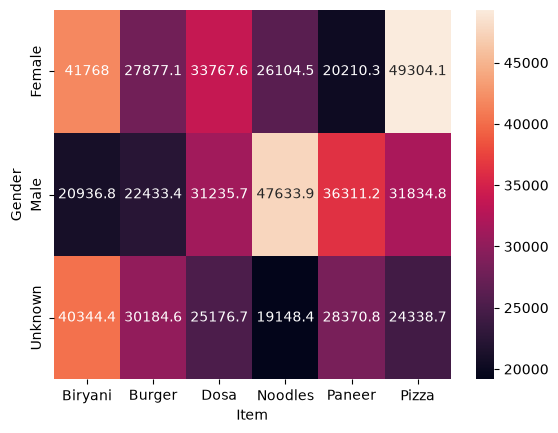

In [75]:
# gender vs item vs amount
pivot_df = df.pivot_table(index ='Gender',columns ='Item',values= 'Total_Amount', aggfunc='sum')
sns.heatmap(pivot_df,annot=True,fmt='g')

<Axes: xlabel='Gender', ylabel='Total_Amount'>

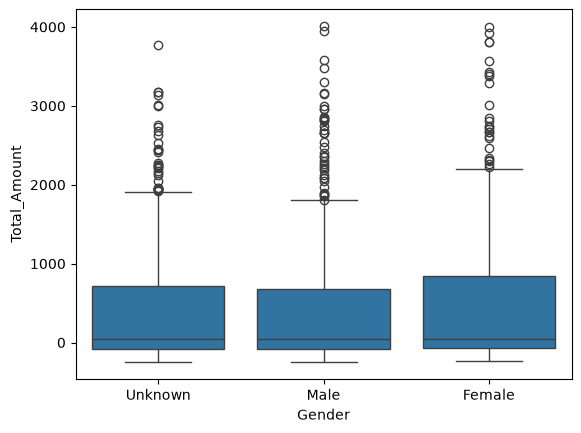

In [76]:
sns.boxplot(x = df["Gender"],y = df["Total_Amount"])

In [77]:
round(df.pivot_table(index ='Gender',columns ='Item',values= 'Total_Amount', aggfunc='count'))

Item,Biryani,Burger,Dosa,Noodles,Paneer,Pizza
Gender,,,,,,
Female,76,56,69,58,42,82
Male,67,60,78,88,70,67
Unknown,60,64,58,53,62,68


In [78]:
# 2. Group by restaurant and city_code, then count items and average the price
result = df.groupby(['Restaurant_Name', 'City']).agg(
    total_items=('Item', 'count'),
    avg_price=('Price', 'mean')
).reset_index().sort_values(by='avg_price',ascending=False)

print(result)

   Restaurant_Name         City  total_items   avg_price
6      Food Palace  bhubaneswar           35  277.945143
20       Spice Hub        delhi           25  277.756000
10     Food Palace       mumbai           27  245.652963
28    Tandoor Town       mumbai           27  236.816296
21       Spice Hub    hyderabad           98  231.603061
9      Food Palace    hyderabad           86  228.191628
29    Tandoor Town         puri           20  228.186500
26    Tandoor Town        delhi           22  221.062727
27    Tandoor Town    hyderabad           97  218.040103
5    Biryani House         puri           34  209.518235
19       Spice Hub      cuttack           33  200.654242
25    Tandoor Town      cuttack           34  198.471176
13     Pizza Point      cuttack           24  198.098333
7      Food Palace      cuttack           37  189.252703
11     Food Palace         puri           37  186.838649
12     Pizza Point  bhubaneswar           30  183.389000
22       Spice Hub       mumbai

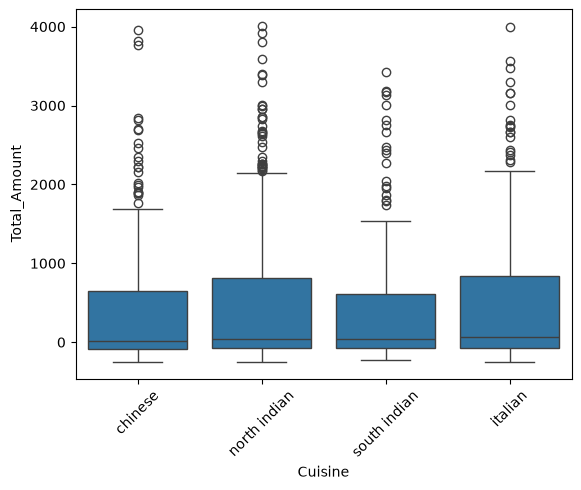

In [79]:
sns.boxplot(data=df, x='Cuisine', y='Total_Amount')
plt.xticks(rotation=45)
plt.show()

In [80]:
def plot_crosstab_heatmap(df, row_col, col_col, title, top_n=None):
    """
    Build a sorted crosstab between row_col and col_col,
    display it as a styled table, and plot it as a heatmap.
    
    top_n: if set, only plots the top_n rows (by Total Orders) in the heatmap
           (table still shows everything)
    """
    # 1. Crosstab with totals
    ct = pd.crosstab(df[row_col], df[col_col], margins=True, margins_name="Total Orders")

    # 2. Sort columns by total, keep "Total Orders" at the end
    cols_sorted = ct.columns.drop("Total Orders").sort_values(
        ascending=False, key=lambda x: ct.loc["Total Orders", x]
    )
    ct = ct[list(cols_sorted) + ["Total Orders"]]

    # 3. Sort rows by total, keep "Total Orders" row at the bottom
    total_row = ct.loc[["Total Orders"]]
    rows_sorted = ct.drop("Total Orders").sort_values(by="Total Orders", ascending=False)
    ct = pd.concat([rows_sorted, total_row])

    # 4. Display styled table
    idx = pd.IndexSlice
    display(
        ct.style.set_properties(
            subset=idx["Total Orders", :], 
            **{"background-color": "#d9eaf2", "font-weight": "bold", "color": "black"}
        ).set_properties(
            subset=idx[:, "Total Orders"], 
            **{"background-color": "#d9eaf2", "font-weight": "bold", "color": "black"}
        )
    )

    # 5. Prep heatmap data (drop totals)
    heatmap_data = ct.drop("Total Orders", axis=0).drop("Total Orders", axis=1)
    if top_n:
        heatmap_data = heatmap_data.head(top_n)

    # 6. Plot
    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues",
                linewidths=0.5, cbar_kws={'label': 'Number of Orders'})
    plt.title(title, fontsize=14, fontweight="bold", pad=15)
    plt.xlabel(col_col, fontsize=12, fontweight="bold")
    plt.ylabel(row_col, fontsize=12, fontweight="bold")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

City,hyderabad,cuttack,delhi,bhubaneswar,puri,mumbai,Total Orders
Restaurant_Name,,,,,,,
Food Palace,86,37,29,35,37,27,251
Spice Hub,98,33,25,33,23,31,243
Biryani House,94,31,38,20,34,23,240
Tandoor Town,97,34,22,25,20,27,225
Pizza Point,85,24,32,30,22,26,219
Total Orders,460,159,146,143,136,134,1178


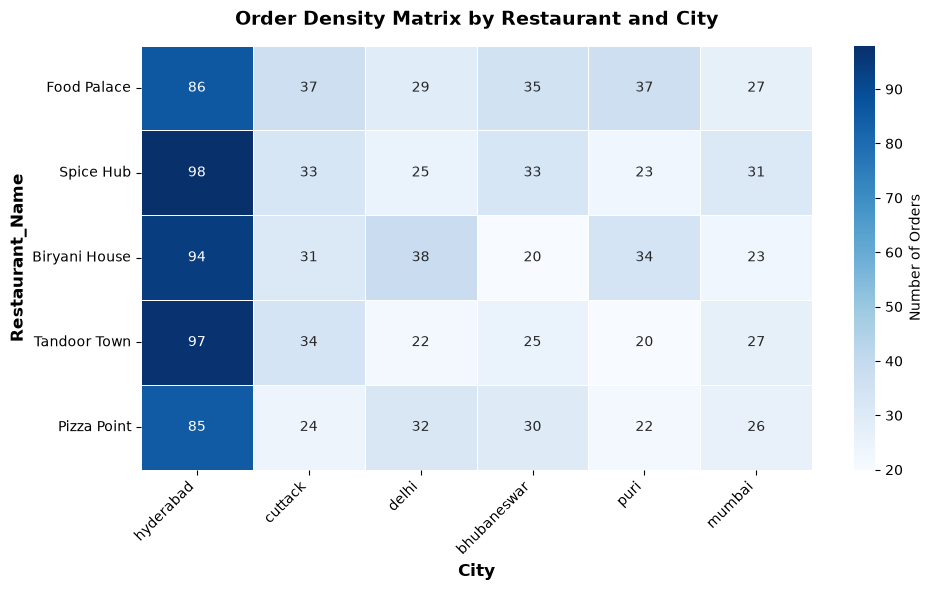

City,hyderabad,cuttack,delhi,bhubaneswar,puri,mumbai,Total Orders
Cuisine,,,,,,,
north indian,230,62,69,67,72,69,569
chinese,76,34,28,28,25,25,216
italian,88,27,23,25,25,19,207
south indian,66,36,26,23,14,21,186
Total Orders,460,159,146,143,136,134,1178


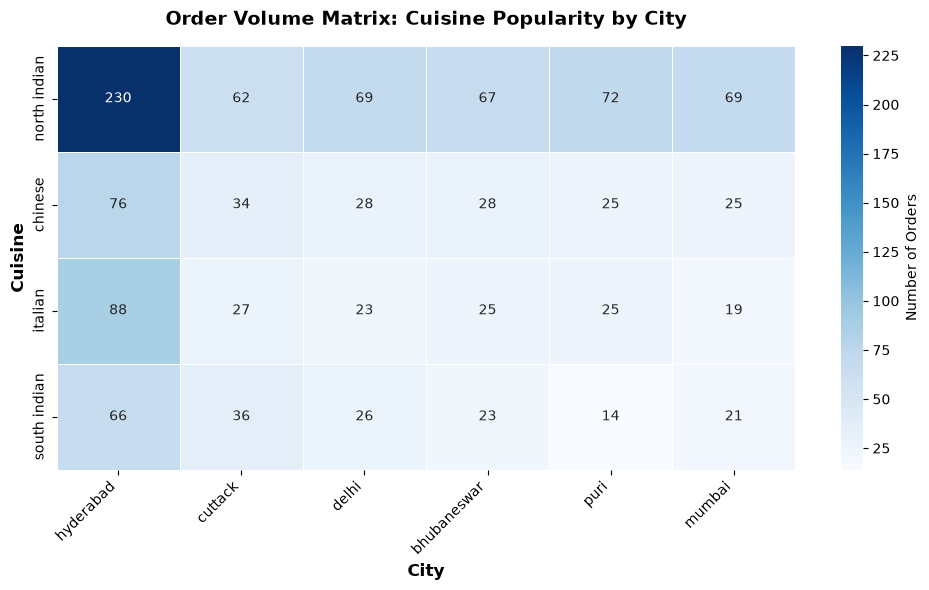

Restaurant_Name,Food Palace,Spice Hub,Biryani House,Tandoor Town,Pizza Point,Total Orders
Cuisine,,,,,,
north indian,119,119,126,94,111,569
chinese,46,40,51,51,28,216
italian,45,49,35,43,35,207
south indian,41,35,28,37,45,186
Total Orders,251,243,240,225,219,1178


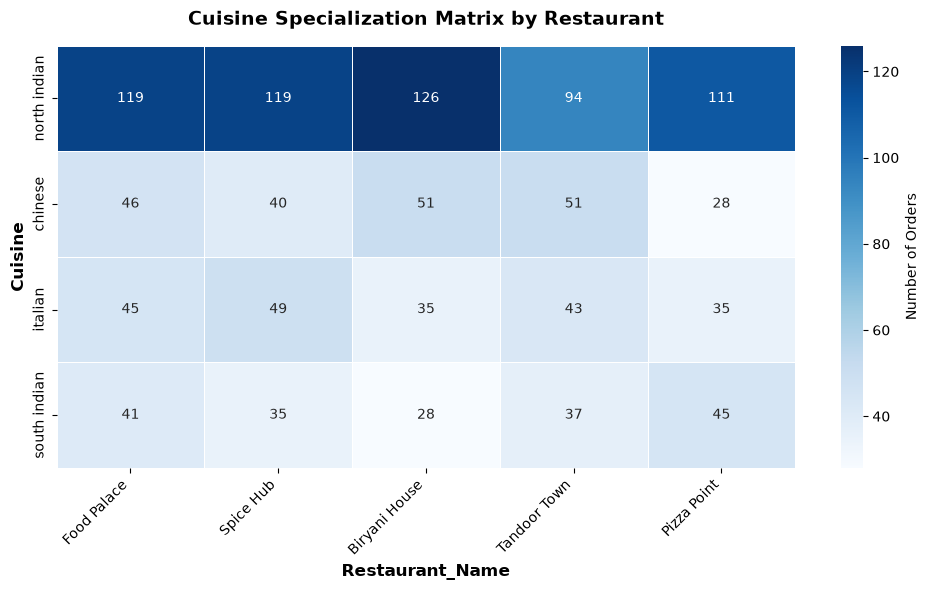

City,hyderabad,cuttack,delhi,bhubaneswar,puri,mumbai,Total Orders
Item,,,,,,,
Pizza,80,26,29,31,24,27,217
Dosa,82,32,24,26,21,20,205
Biryani,92,27,21,22,28,13,203
Noodles,79,26,22,16,27,29,199
Burger,71,24,19,25,23,18,180
Paneer,56,24,31,23,13,27,174
Total Orders,460,159,146,143,136,134,1178


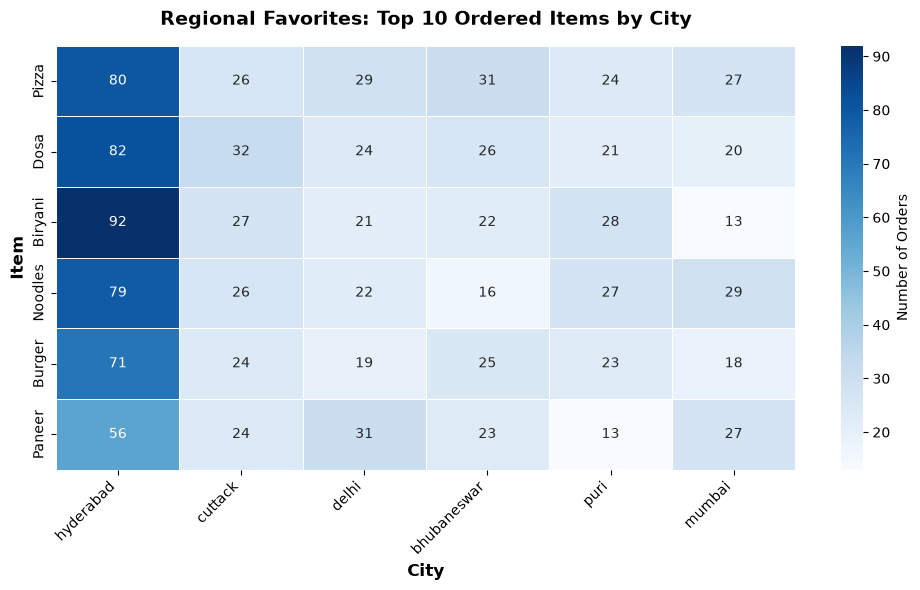

Restaurant_Name,Food Palace,Spice Hub,Biryani House,Tandoor Town,Pizza Point,Total Orders
Item,,,,,,
Pizza,39,49,46,41,42,217
Dosa,47,47,29,42,40,205
Biryani,45,32,47,41,38,203
Noodles,40,46,40,31,42,199
Burger,45,33,41,36,25,180
Paneer,35,36,37,34,32,174
Total Orders,251,243,240,225,219,1178


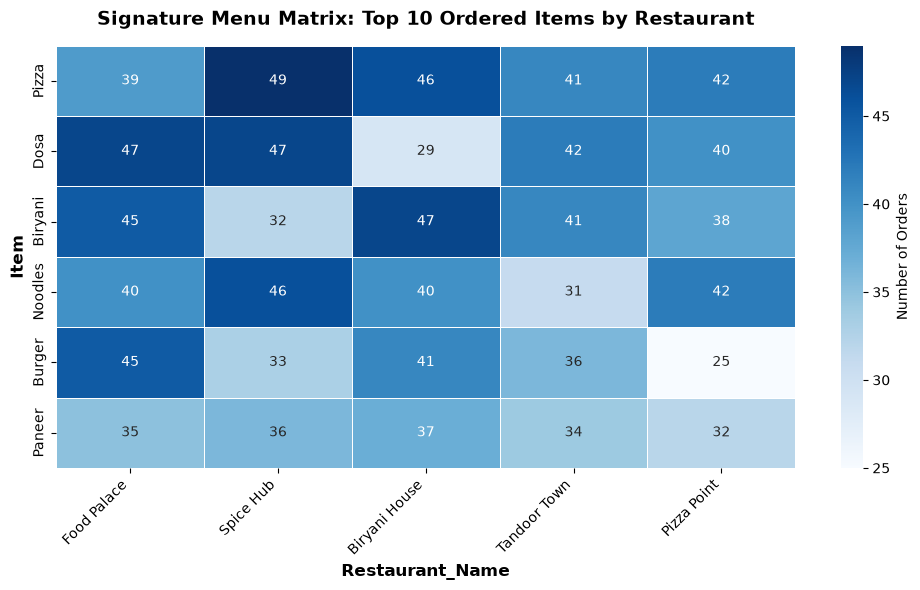

In [81]:
plot_crosstab_heatmap(df, "Restaurant_Name", "City", "Order Density Matrix by Restaurant and City")

plot_crosstab_heatmap(df, "Cuisine", "City", "Order Volume Matrix: Cuisine Popularity by City")

plot_crosstab_heatmap(df, "Cuisine", "Restaurant_Name", "Cuisine Specialization Matrix by Restaurant")

plot_crosstab_heatmap(df, "Item", "City", "Regional Favorites: Top 10 Ordered Items by City", top_n=10)

plot_crosstab_heatmap(df, "Item", "Restaurant_Name", "Signature Menu Matrix: Top 10 Ordered Items by Restaurant", top_n=10)

In [82]:
df['Cuisine'].unique()

<StringArray>
['chinese', 'north indian', 'south indian', 'italian']
Length: 4, dtype: str

***Performing Advance Statistics And Probability***

In [83]:
total_restaurants = len(df["Restaurant_Name"].unique())
# print(total_restaurants)
south_indian_count = df[df['Cuisine'] == 'south indian'].shape[0]
probability_of_south_indian_item = south_indian_count/total_restaurants
print(f'probability of randomly select a south indian item : {probability_of_south_indian_item} %')

probability of randomly select a south indian item : 37.2 %
